1. Charger le dataset & afficher data structre

In [1]:
import pandas as pd

df = pd.read_excel("../data/data.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print("Nombre de lignes et colonnes :", df.shape)

print("\n Colonnes :")
print(df.columns.tolist())

print("\n Informations generales :")
df.info()

print("\n Valeurs manquantes :")
print(df.isna().sum())

print("\n Lignes dupliquees :", df.duplicated().sum())

Nombre de lignes et colonnes : (541909, 8)

 Colonnes :
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

 Informations generales :
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB

 Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDat

In [10]:
print("Dimensions :", df.shape)
print("Doublons :", df.duplicated().sum())

print("\n Valeurs manquantes :")
print(df.isna().sum())

print("\n Quantites negatives :", (df["Quantity"] < 0).sum())
print("Prix negatifs :", (df["UnitPrice"] < 0).sum())
print("Prix nuls :", (df["UnitPrice"] == 0).sum())

print(
    "Factures annulees :",
    df["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Dimensions : (541909, 8)
Doublons : 5268

 Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 Quantites negatives : 10624
Prix negatifs : 2
Prix nuls : 2515
Factures annulees : 9288


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


2. Distribution des variables numeriques

array([[<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'UnitPrice'}>]], dtype=object)

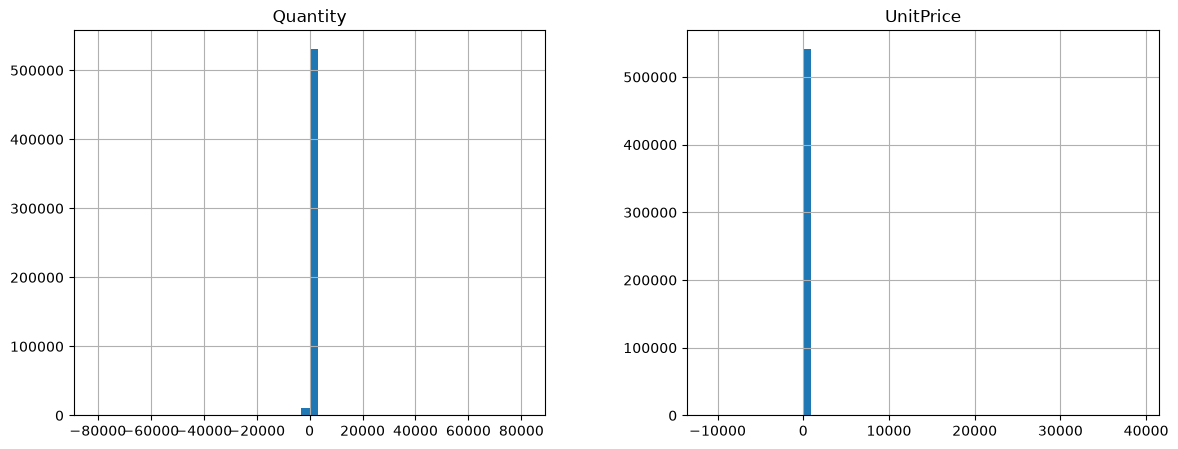

In [5]:
df[["Quantity", "UnitPrice"]].hist(bins=50, figsize=(14, 5))


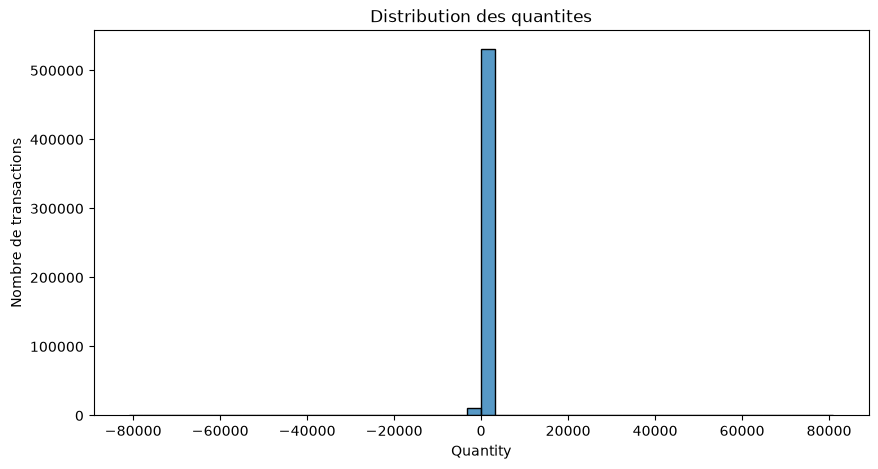

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Quantity", bins=50)

plt.title("Distribution des quantites")
plt.xlabel("Quantity")
plt.ylabel("Nombre de transactions")
plt.show()

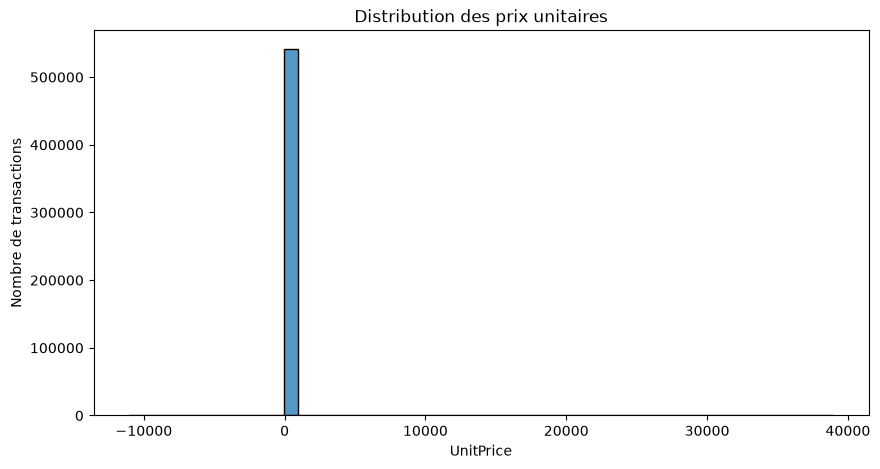

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="UnitPrice", bins=50)

plt.title("Distribution des prix unitaires")
plt.xlabel("UnitPrice")
plt.ylabel("Nombre de transactions")
plt.show()

Text(0, 0.5, 'Produit')

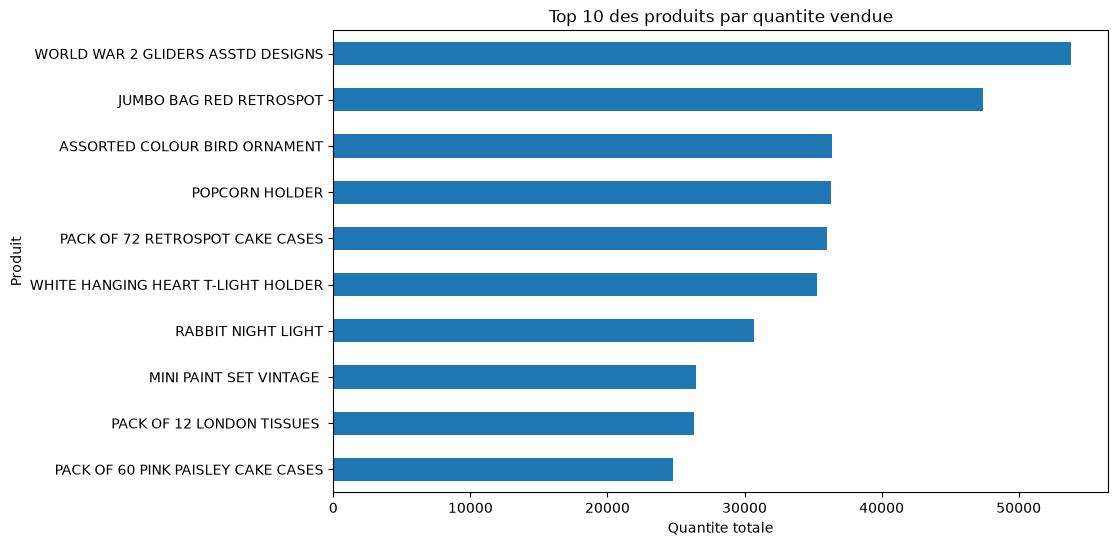

In [8]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top_products.plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 des produits par quantite vendue")
plt.xlabel("Quantite totale")
plt.ylabel("Produit")